# Direction Model v2
**Changes vs v1:**
- Target: `sign(mfe_long_pips > mfe_short_pips)` instead of 8h log return
- Features: directional-only subset (flow, momentum, range, CSI/relstr, candle)
- Drops microstructure features designed to detect *when* moves happen


In [5]:
import joblib, warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
from pathlib import Path
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score
warnings.filterwarnings("ignore")

FEATURES_DIR   = Path("../backend/data/features_9")
MFE_MODEL_PATH = Path("../backend/models_9/mfe_q50_8h/model_1H_Q50.joblib")
OUTPUT_DIR     = Path("../backend/models_9/dir_v2_8h")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_END  = "2024-06-30"
MFE_THRESH = 30.0
N_FOLDS    = 5

FLOW_FEATURES = [
    "order_imbalance", "order_imbalance_intensity", "buy_volume_frac",
    "order_imbalance_delta_3h", "order_imbalance_delta_6h", "order_imbalance_delta_12h",
]
MOMENTUM_FEATURES = [
    "ret_1d", "ret_3d", "ret_1w", "ret_2w",
    "momentum_shift", "accel_mean",
]
RANGE_FEATURES = [
    "range_pos_24", "range_pos_48", "range_pos_5d", "range_pos_10d",
    "dist_from_24h_high", "dist_from_24h_low",
    "dist_5d_high", "dist_5d_low",
    "range_width_24", "range_width_48", "range_width_5d",
]
CANDLE_FEATURES = [
    "body_ratio", "candle_direction", "consec_bullish", "consec_bearish",
    "upper_wick_ratio", "lower_wick_ratio",
]
SESSION_FEATURES = [
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_london", "is_ny", "is_asia", "is_overlap",
    "is_month_end", "days_to_friday",
]
VOL_CONTEXT = ["atr_ratio_6_24", "atr_ratio_6_72", "vol_regime_5d", "vol_regime_10d", "vol_trend"]

print("Config loaded.")


Config loaded.


In [6]:
print("Loading features_9...")
dfs = [pd.read_parquet(f) for f in sorted(FEATURES_DIR.glob("*_features.parquet"))]
df  = pd.concat(dfs).sort_index()
print(f"  Total rows: {len(df):,} | Pairs: {df['pair'].nunique()}")

cols = df.columns.tolist()
CSI_RELSTR_FEATURES = [c for c in cols if c.startswith(("csi_", "relstr_", "peer_", "corr_", "beta_"))]
print(f"  CSI/relstr/peer/corr/beta: {len(CSI_RELSTR_FEATURES)}")

FEATURE_COLS = []
for group in [FLOW_FEATURES, MOMENTUM_FEATURES, RANGE_FEATURES,
              CANDLE_FEATURES, CSI_RELSTR_FEATURES, SESSION_FEATURES, VOL_CONTEXT]:
    FEATURE_COLS += [f for f in group if f in cols]
seen = set()
FEATURE_COLS = [f for f in FEATURE_COLS if not (f in seen or seen.add(f))]
print(f"  Directional feature cols: {len(FEATURE_COLS)}")


Loading features_9...
  Total rows: 1,518,020 | Pairs: 15
  CSI/relstr/peer/corr/beta: 192
  Directional feature cols: 236


In [7]:
df["dir_target"] = (df["mfe_long_pips"] > df["mfe_short_pips"]).astype(int)

print("Running MFE model...")
mfe_bundle    = joblib.load(MFE_MODEL_PATH)
mfe_model     = mfe_bundle["model"]
mfe_feat_cols = mfe_bundle["feature_cols"]
for col in mfe_feat_cols:
    if col not in df.columns:
        df[col] = 0.0
X_mfe = df[mfe_feat_cols].ffill().fillna(0)
df["q50_mfe"] = mfe_model.predict(X_mfe)

df_sig = df[
    (df["q50_mfe"] >= MFE_THRESH) &
    df["mfe_long_pips"].notna() &
    df["mfe_short_pips"].notna()
].copy()
print(f"  Signal bars (MFE>={MFE_THRESH}): {len(df_sig):,}")
print(f"  Long: {df_sig['dir_target'].mean():.2%}  |  Short: {1-df_sig['dir_target'].mean():.2%}")

df_train = df_sig[df_sig.index <= TRAIN_END].copy()
df_test  = df_sig[df_sig.index >  TRAIN_END].copy()
print(f"  Train: {len(df_train):,} | Test: {len(df_test):,}")


Running MFE model...
  Signal bars (MFE>=30.0): 488,505
  Long: 45.92%  |  Short: 54.08%
  Train: 422,978 | Test: 65,527


In [8]:
df_train_sorted = df_train.sort_index()
X_all = df_train_sorted[FEATURE_COLS].ffill().fillna(0).to_numpy()
y_all = df_train_sorted["dir_target"].to_numpy()
n     = len(X_all)

fold_size = n // N_FOLDS
folds_pos = []
for i in range(N_FOLDS):
    tr_end = fold_size * (i + 1)
    te_end = min(fold_size * (i + 2), n)
    if te_end <= tr_end: break
    folds_pos.append((slice(0, tr_end), slice(tr_end, te_end)))

LGB_PARAMS = dict(
    objective="binary", metric="binary_logloss",
    learning_rate=0.05, num_leaves=31,
    min_child_samples=50, feature_fraction=0.7,
    bagging_fraction=0.8, bagging_freq=5,
    lambda_l1=0.1, lambda_l2=0.1, verbose=-1,
)

oof_preds = np.full(n, np.nan)
oof_iters = []

for fold_i, (tr, te) in enumerate(folds_pos):
    X_tr, y_tr = X_all[tr], y_all[tr]
    X_te, y_te = X_all[te], y_all[te]
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval   = lgb.Dataset(X_te, label=y_te, reference=dtrain)
    m = lgb.train(LGB_PARAMS, dtrain, num_boost_round=500,
                  valid_sets=[dval],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
    preds = m.predict(X_te)
    oof_preds[te] = preds
    oof_iters.append(m.best_iteration)
    n_classes = len(np.unique(y_te))
    auc_str  = f"{roc_auc_score(y_te, preds):.3f}" if n_classes > 1 else "n/a"
    loss_str = f"{log_loss(y_te, preds):.4f}"      if n_classes > 1 else "n/a"
    print(f"  Fold {fold_i+1}: iters={m.best_iteration} | "
          f"acc={accuracy_score(y_te, preds>=0.5):.3f} | "
          f"AUC={auc_str} | logloss={loss_str}")

mask = ~np.isnan(oof_preds)
oof_acc  = accuracy_score(y_all[mask], oof_preds[mask] >= 0.5)
oof_auc  = roc_auc_score(y_all[mask], oof_preds[mask])
best_iters = int(np.mean(oof_iters) * 1.1)
print(f"OOF: acc={oof_acc:.3f} | AUC={oof_auc:.3f} | final iters -> {best_iters}")


  Fold 1: iters=11 | acc=0.513 | AUC=0.518 | logloss=0.6927
  Fold 2: iters=3 | acc=0.509 | AUC=0.518 | logloss=0.6928
  Fold 3: iters=3 | acc=0.520 | AUC=0.490 | logloss=0.6928
  Fold 4: iters=211 | acc=0.610 | AUC=0.594 | logloss=0.6570
  Fold 5: iters=1 | acc=0.000 | AUC=n/a | logloss=n/a
OOF: acc=0.538 | AUC=0.548 | final iters -> 50


In [9]:
X_train_full = df_train_sorted[FEATURE_COLS].ffill().fillna(0).to_numpy()
y_train_full = df_train_sorted["dir_target"].to_numpy()
final_model = lgb.train(LGB_PARAMS, lgb.Dataset(X_train_full, label=y_train_full),
                        num_boost_round=best_iters, callbacks=[lgb.log_evaluation(-1)])
print(f"Final model: {best_iters} iters, {len(FEATURE_COLS)} features")

X_test     = df_test[FEATURE_COLS].ffill().fillna(0).to_numpy()
y_test     = df_test["dir_target"].to_numpy()
test_preds = final_model.predict(X_test)

test_acc  = accuracy_score(y_test, test_preds >= 0.5)
test_auc  = roc_auc_score(y_test, test_preds)
print(f"Test (post {TRAIN_END}):")
print(f"  Accuracy : {test_acc:.3f}  (baseline always-short: {1-y_test.mean():.3f})")
print(f"  AUC      : {test_auc:.3f}  (baseline: 0.500)")
print(f"  Log loss : {log_loss(y_test, test_preds):.4f}")


Final model: 50 iters, 236 features
Test (post 2024-06-30):
  Accuracy : 0.601  (baseline always-short: 0.597)
  AUC      : 0.607  (baseline: 0.500)
  Log loss : 0.6546


In [10]:
print("Threshold sweep:")
print(f"  {'Thresh':>8} {'N_long':>8} {'N_short':>8} {'WR_long':>9} {'WR_short':>9} {'Overall':>9}")
print(f"  {'-'*60}")
for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred_dir = (test_preds >= thresh).astype(int)
    mask_l = pred_dir == 1; mask_s = pred_dir == 0
    acc_l = y_test[mask_l].mean()      if mask_l.sum() > 0 else float("nan")
    acc_s = (1-y_test[mask_s]).mean()  if mask_s.sum() > 0 else float("nan")
    print(f"  {thresh:>8.2f} {mask_l.sum():>8,} {mask_s.sum():>8,} "
          f"{acc_l:>9.3f} {acc_s:>9.3f} {accuracy_score(y_test, pred_dir):>9.3f}")

print("\nPrediction bucket -> actual long rate:")
for lo, hi in [(0,.3),(.3,.4),(.4,.5),(.5,.6),(.6,.7),(.7,1.01)]:
    mask = (test_preds >= lo) & (test_preds < hi)
    if mask.sum() < 10: continue
    print(f"  [{lo:.1f}-{hi:.1f}): n={mask.sum():>5,}  long_rate={y_test[mask].mean():.3f}")


Threshold sweep:
    Thresh   N_long  N_short   WR_long  WR_short   Overall
  ------------------------------------------------------------
      0.30   59,583    5,944     0.425     0.820     0.461
      0.35   54,679   10,848     0.439     0.777     0.495
      0.40   47,520   18,007     0.457     0.739     0.534
      0.45   33,105   32,422     0.475     0.670     0.571
      0.50    3,226   62,301     0.538     0.604     0.601
      0.55      604   64,923     0.710     0.600     0.601
      0.60      363   65,164     0.777     0.599     0.600

Prediction bucket -> actual long rate:
  [0.0-0.3): n=5,944  long_rate=0.180
  [0.3-0.4): n=12,063  long_rate=0.301
  [0.4-0.5): n=44,294  long_rate=0.451
  [0.5-0.6): n=2,863  long_rate=0.507
  [0.6-0.7): n=  218  long_rate=0.716
  [0.7-1.0): n=  145  long_rate=0.869


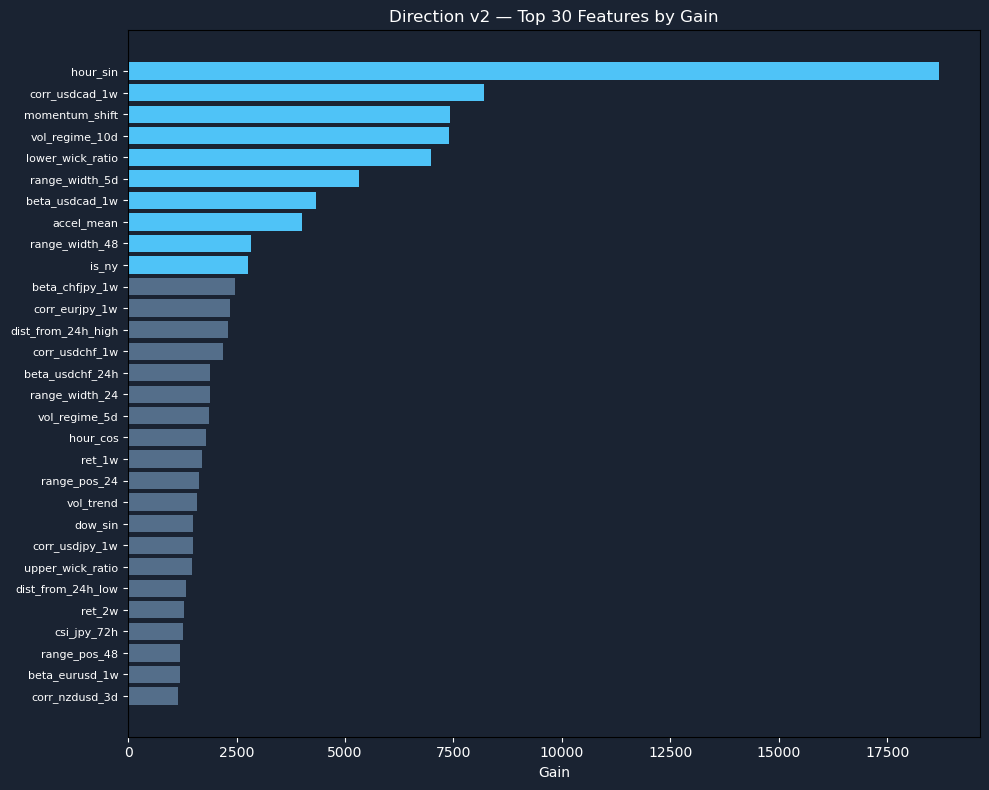


Top 20 features:
  hour_sin                                      18706
  corr_usdcad_1w                                 8211
  momentum_shift                                 7415
  vol_regime_10d                                 7401
  lower_wick_ratio                               6981
  range_width_5d                                 5317
  beta_usdcad_1w                                 4341
  accel_mean                                     4012
  range_width_48                                 2823
  is_ny                                          2766
  beta_chfjpy_1w                                 2459
  corr_eurjpy_1w                                 2340
  dist_from_24h_high                             2295
  corr_usdchf_1w                                 2193
  beta_usdchf_24h                                1898
  range_width_24                                 1883
  vol_regime_5d                                  1861
  hour_cos                                       1797
  ret_1w  

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 8), facecolor="#1a2332")
ax.set_facecolor("#1a2332")
importance = pd.Series(
    final_model.feature_importance(importance_type="gain"), index=FEATURE_COLS
).sort_values(ascending=False).head(30)
colors = ["#4fc3f7" if i < 10 else "#546e8a" for i in range(len(importance))]
ax.barh(range(len(importance)), importance.values[::-1], color=colors[::-1])
ax.set_yticks(range(len(importance)))
ax.set_yticklabels(importance.index[::-1], color="white", fontsize=8)
ax.set_xlabel("Gain", color="white"); ax.tick_params(colors="white")
ax.set_title("Direction v2 — Top 30 Features by Gain", color="white", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_v2.png", dpi=120, bbox_inches="tight", facecolor="#1a2332")
plt.show()
print("\nTop 20 features:")
for feat, imp in importance.head(20).items():
    print(f"  {feat:<40} {imp:>10.0f}")


In [12]:
df_te = df_test.copy()
df_te["pred"]     = test_preds
df_te["pred_dir"] = (test_preds >= 0.5).astype(int)
df_te["correct"]  = (df_te["pred_dir"] == df_te["dir_target"])
print(f"{'Pair':<10} {'N':>6} {'Acc':>7} {'AUC':>7} {'Long%':>7} {'Pred_L%':>8} {'Base':>7}")
print("-" * 60)
for pair in sorted(df_te["pair"].unique()):
    s = df_te[df_te["pair"] == pair]
    if len(s) < 30: continue
    acc  = s["correct"].mean()
    base = 1 - s["dir_target"].mean()
    try: auc = roc_auc_score(s["dir_target"], s["pred"])
    except: auc = float("nan")
    print(f"{pair:<10} {len(s):>6,} {acc:>7.3f} {auc:>7.3f} "
          f"{s['dir_target'].mean():>7.2%} {s['pred_dir'].mean():>8.2%} {base:>7.3f}")


Pair            N     Acc     AUC   Long%  Pred_L%    Base
------------------------------------------------------------
AUDJPY      5,979   0.627   0.607  37.38%    7.61%   0.626
AUDNZD      5,442   0.825   0.617  18.08%    1.16%   0.819
AUDUSD        994   0.592   0.630  43.76%    6.14%   0.562
CADJPY      5,884   0.617   0.585  38.46%    6.82%   0.615
CHFJPY      8,732   0.652   0.637  35.07%    2.19%   0.649
EURAUD      7,940   0.602   0.612  39.80%    1.25%   0.602
EURGBP      1,095   0.719   0.685  30.59%    3.01%   0.694
EURJPY      8,025   0.530   0.528  47.26%    5.74%   0.527
EURUSD      1,083   0.456   0.525  55.49%    2.59%   0.445
GBPJPY      8,624   0.527   0.528  47.52%    7.13%   0.525
GBPUSD      1,938   0.477   0.503  52.12%    2.84%   0.479
NZDUSD      1,280   0.677   0.652  34.61%    4.30%   0.654
USDCAD      1,047   0.606   0.538  40.97%    5.06%   0.590
USDCHF      1,063   0.544   0.495  45.72%    8.00%   0.543
USDJPY      6,401   0.525   0.512  47.95%    8.92%   0

In [13]:
bundle = {
    "model":        final_model,
    "feature_cols": FEATURE_COLS,
    "target":       "sign(mfe_long > mfe_short)",
    "train_end":    TRAIN_END,
    "mfe_thresh":   MFE_THRESH,
    "n_iters":      best_iters,
    "oof_acc":      oof_acc,
    "oof_auc":      oof_auc,
    "test_acc":     test_acc,
    "test_auc":     test_auc,
}
out_path = OUTPUT_DIR / "model_1H_dir_v2.joblib"
joblib.dump(bundle, out_path)
print(f"Saved: {out_path}")
print(f"OOF  acc={oof_acc:.3f} | AUC={oof_auc:.3f}")
print(f"Test acc={test_acc:.3f} | AUC={test_auc:.3f}")


Saved: ..\backend\models_9\dir_v2_8h\model_1H_dir_v2.joblib
OOF  acc=0.538 | AUC=0.548
Test acc=0.601 | AUC=0.607
